In [255]:
#pip install datasets

In [256]:
#pip install matplotlib

In [257]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [258]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Предобработка

In [259]:
from datasets import load_dataset

df = load_dataset("yandex/yambda", name="flat-multievent-50m", split="train")

df = df.to_pandas()
df.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
0,100,39420,8326270,0,100.00,170.00,listen
1,100,39420,1441281,0,100.00,105.00,listen
2,100,39625,286361,0,100.00,185.00,listen
3,100,40110,732449,0,100.00,240.00,listen
4,100,40360,3397170,0,46.00,130.00,listen


In [260]:
df.dtypes

uid                      uint32
timestamp                uint32
item_id                  uint32
is_organic                uint8
played_ratio_pct        float64
track_length_seconds    float64
event_type                  str
dtype: object

<Axes: >

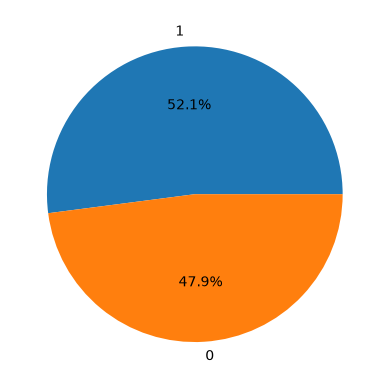

In [261]:
df.is_organic.value_counts().plot(kind="pie", autopct="%1.1f%%")

In [262]:
df.is_organic.value_counts()

is_organic
1    24876996
0    22913453
Name: count, dtype: int64

<Axes: xlabel='event_type'>

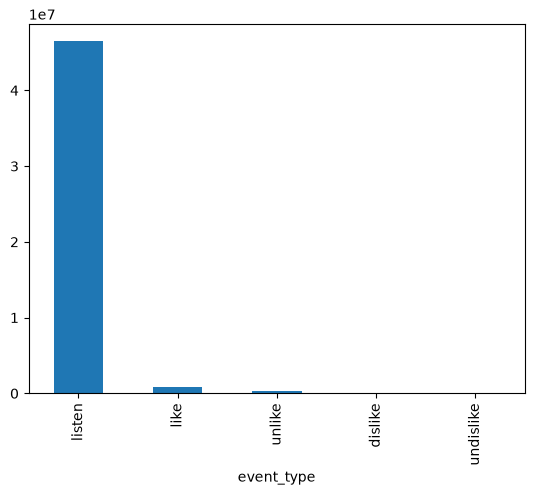

In [263]:
df.event_type.value_counts().plot(kind="bar")

In [264]:
df.event_type.value_counts()

event_type
listen       46467212
like           881456
unlike         312972
dislike        107776
undislike       21033
Name: count, dtype: int64

In [265]:
df[[ 'timestamp', 'played_ratio_pct', 'track_length_seconds']].describe()

,timestamp,played_ratio_pct,track_length_seconds
count,47790449.00,46467212.00,46467212.00
mean,14446548.21,64.76,207.41
std,7469606.18,44.09,89.21
min,0.00,0.00,5.00
25%,8185690.00,7.00,165.00
50%,15090975.00,100.00,200.00
75%,21061390.00,100.00,230.00
max,26000000.00,159.00,2495.00


Работаем только с неорганическими данными:

In [266]:
non_organic = df[df.is_organic == False].copy()
non_organic = non_organic.drop(columns=['is_organic'])
non_organic.head()

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type
0,100,39420,8326270,100.00,170.00,listen
1,100,39420,1441281,100.00,105.00,listen
2,100,39625,286361,100.00,185.00,listen
3,100,40110,732449,100.00,240.00,listen
4,100,40360,3397170,46.00,130.00,listen


In [267]:
non_organic.event_type.value_counts()

event_type
listen       22463555
like           379255
dislike         51788
unlike          16531
undislike        2324
Name: count, dtype: int64

In [268]:
non_organic[[ 'timestamp', 'played_ratio_pct', 'track_length_seconds']].describe()

,timestamp,played_ratio_pct,track_length_seconds
count,22913453.00,22463555.00,22463555.00
mean,14302605.78,69.61,201.19
std,7537120.61,42.51,70.28
min,0.00,0.00,5.00
25%,7896020.00,16.00,165.00
50%,14884490.00,100.00,195.00
75%,21035230.00,100.00,230.00
max,26000000.00,159.00,2495.00


In [269]:
non_organic['is_listen'] = non_organic['event_type'] == 'listen'
non_organic['is_like'] = non_organic['event_type'] == 'like'
non_organic['is_dislike'] = non_organic['event_type'] == 'dislike'

non_organic['is_full_play'] = (non_organic['event_type'] == 'listen') & (non_organic['played_ratio_pct'] >= 90)
non_organic['is_skip'] = (non_organic['event_type'] == 'listen') & (non_organic['played_ratio_pct'] < 50)

non_organic  = non_organic.sort_values(["uid", "timestamp", "event_type", "item_id"], kind="mergesort")
non_organic.head()

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type,is_listen,is_like,is_dislike,is_full_play,is_skip
1,100,39420,1441281,100.00,105.00,listen,True,False,False,True,False
0,100,39420,8326270,100.00,170.00,listen,True,False,False,True,False
2,100,39625,286361,100.00,185.00,listen,True,False,False,True,False
3,100,40110,732449,100.00,240.00,listen,True,False,False,True,False
4,100,40360,3397170,46.00,130.00,listen,True,False,False,False,True


In [270]:
listens = non_organic.loc[non_organic["is_listen"]].copy().reset_index(drop=True)
listens["listen_row_id"] = np.arange(len(listens), dtype=np.int64)

likes = non_organic.loc[non_organic["is_like"]].copy().reset_index(drop=True)
likes["like_idx"] = np.arange(len(likes), dtype=np.int64)

dislikes = non_organic.loc[non_organic["is_dislike"]].copy().reset_index(drop=True)
dislikes["dislike_idx"] = np.arange(len(dislikes), dtype=np.int64)

In [271]:
listens_new = listens[["uid", "item_id", "timestamp", "listen_row_id"]].rename(
    columns={"timestamp": "listen_ts"}
).sort_values(["listen_ts", "uid", "item_id"], kind="mergesort")

likes_new = likes[["uid", "item_id", "timestamp", "like_idx"]].rename(
    columns={"timestamp": "like_ts"}
).sort_values(["like_ts", "uid", "item_id"], kind="mergesort")

dislikes_new = dislikes[["uid", "item_id", "timestamp", "dislike_idx"]].rename(
    columns={"timestamp": "dislike_ts"}
).sort_values(["dislike_ts", "uid", "item_id"], kind="mergesort")

listens_new.head()

,uid,item_id,listen_ts,listen_row_id
10651722,468300,7400764,0,10651722
7761463,347600,3415205,5,7761463
21259899,942900,6728180,10,21259899
223234,12700,8932363,15,223234
14214139,631600,1652612,20,14214139


In [272]:
likes_new.head()

,uid,item_id,like_ts,like_idx
68803,190800,2214045,80,68803
233323,631600,1652612,1190,233323
129295,347600,1777844,2615,129295
80513,219100,1402386,2690,80513
186181,496700,2581708,3725,186181


In [273]:
dislikes_new.head()

,uid,item_id,dislike_ts,dislike_idx
33651,607000,8876988,6700,33651
33652,607000,5950157,7605,33652
40833,763600,4384330,10370,40833
36058,647400,3079656,12505,36058
36059,647400,4335158,12505,36059


In [274]:
prev_l = pd.merge_asof(
    likes_new,
    listens_new,
    left_on="like_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="backward",
).rename(columns={"listen_ts": "prev_listen_ts", "listen_row_id": "prev_listen_id"})

next_l = pd.merge_asof(
    likes_new,
    listens_new,
    left_on="like_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="forward",
).rename(columns={"listen_ts": "next_listen_ts", "listen_row_id": "next_listen_id"})

both_l = prev_l.merge(
    next_l[["like_idx", "next_listen_ts", "next_listen_id"]],
    on="like_idx",
    how="left",
)

In [275]:
prev_d = pd.merge_asof(
    dislikes_new,
    listens_new,
    left_on="dislike_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="backward",
).rename(columns={"listen_ts": "prev_listen_ts", "listen_row_id": "prev_listen_id"})

next_d = pd.merge_asof(
    dislikes_new,
    listens_new,
    left_on="dislike_ts",
    right_on="listen_ts",
    by=["uid", "item_id"],
    direction="forward",
).rename(columns={"listen_ts": "next_listen_ts", "listen_row_id": "next_listen_id"})

both_d = prev_d.merge(
    next_d[["dislike_idx", "next_listen_ts", "next_listen_id"]],
    on="dislike_idx",
    how="left",
)

Будем привязывать действие либо к ближайшему предыдущему прослушиванию за последние 3 часа, либо к последующему прослушиванию в рамках короткого окна (2 * макс. длина трека в датасете) на случай, если прослушивание логируется не одновременно с действием.

In [276]:
window_prev = 3 * 60 * 60
window_next =  2495 * 2

In [277]:
both_l["d_prev"] = (both_l["like_ts"] - both_l["prev_listen_ts"]).abs()
both_l.loc[both_l["prev_listen_ts"].isna(), "d_prev"] = np.nan
    
both_l["d_next"] = (both_l["next_listen_ts"] - both_l["like_ts"]).abs()
both_l.loc[both_l["next_listen_ts"].isna(), "d_next"] = np.nan

cand_prev_ok_l = both_l["prev_listen_ts"].notna() & (both_l["d_prev"] <= window_prev)
cand_next_ok_l = both_l["next_listen_ts"].notna() & (both_l["d_next"] <= window_next)

pick_prev_l = cand_prev_ok_l & (~cand_next_ok_l | (both_l["d_prev"] <= both_l["d_next"]))
pick_next_l = cand_next_ok_l & (~cand_prev_ok_l | (both_l["d_next"] < both_l["d_prev"]))

both_l["_chosen_listen_id"] = pd.Series(pd.NA, index=both_l.index, dtype="Int64")
both_l.loc[pick_prev_l, "_chosen_listen_id"] = both_l.loc[pick_prev_l, "prev_listen_id"].astype("Int64")
both_l.loc[pick_next_l, "_chosen_listen_id"] = both_l.loc[pick_next_l, "next_listen_id"].astype("Int64")


In [278]:
both_d["d_prev"] = (both_d["dislike_ts"] - both_d["prev_listen_ts"]).abs()
both_d.loc[both_d["prev_listen_ts"].isna(), "d_prev"] = np.nan
    
both_d["d_next"] = (both_d["next_listen_ts"] - both_d["dislike_ts"]).abs()
both_d.loc[both_d["next_listen_ts"].isna(), "d_next"] = np.nan

cand_prev_ok_d = both_d["prev_listen_ts"].notna() & (both_d["d_prev"] <= window_prev)
cand_next_ok_d = both_d["next_listen_ts"].notna() & (both_d["d_next"] <= window_next)

pick_prev_d = cand_prev_ok_d & (~cand_next_ok_d | (both_d["d_prev"] <= both_d["d_next"]))
pick_next_d = cand_next_ok_d & (~cand_prev_ok_d | (both_d["d_next"] < both_d["d_prev"]))

both_d["_chosen_listen_id"] = pd.Series(pd.NA, index=both_d.index, dtype="Int64")
both_d.loc[pick_prev_d, "_chosen_listen_id"] = both_d.loc[pick_prev_d, "prev_listen_id"].astype("Int64")
both_d.loc[pick_next_d, "_chosen_listen_id"] = both_d.loc[pick_next_d, "next_listen_id"].astype("Int64")

In [279]:
liked_ids = (
    both_l.loc[both_l["_chosen_listen_id"].notna(), ["_chosen_listen_id"]]
    .rename(columns={"_chosen_listen_id": "listen_row_id"})
    .drop_duplicates()
)

disliked_ids = (
    both_d.loc[both_d["_chosen_listen_id"].notna(), ["_chosen_listen_id"]]
    .rename(columns={"_chosen_listen_id": "listen_row_id"})
    .drop_duplicates()
)

listens = listens.merge(
    liked_ids.assign(_has_like=True),
    on="listen_row_id",
    how="left",
)
listens["is_like"] = listens["_has_like"].fillna(False).astype(bool)

listens = listens.merge(
    disliked_ids.assign(_has_dislike=True),
    on="listen_row_id",
    how="left",
)
listens["is_dislike"] = listens["_has_dislike"].fillna(False).astype(bool)

listens = listens.drop(
    columns=["listen_row_id", "_has_like", "_has_dislike", "is_listen", "event_type"],
    errors="ignore",
)

In [280]:
listens.head()

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_dislike,is_full_play,is_skip
0,100,39420,1441281,100.00,105.00,False,False,True,False
1,100,39420,8326270,100.00,170.00,False,False,True,False
2,100,39625,286361,100.00,185.00,False,False,True,False
3,100,40110,732449,100.00,240.00,False,False,True,False
4,100,40360,3397170,46.00,130.00,False,False,False,True


In [281]:
listens.is_like.value_counts()

is_like
False    22087983
True       375572
Name: count, dtype: int64

In [282]:
listens.is_dislike.value_counts()

is_dislike
False    22412319
True        51236
Name: count, dtype: int64

In [283]:
def _cum_timeline(events, group, prefix):
    sort_cols = list(dict.fromkeys([*group, "timestamp", "event_type", "item_id"]))

    ev = events.sort_values(sort_cols, kind="mergesort").copy()

    ev["played_sum"] = (
        ev["played_ratio_pct"]
        .fillna(0)
        .astype("int64")
        * ev["is_listen"].astype("int64")
    )

    g = ev.groupby(group, sort=False)

    ev[f"{prefix}_c_listen"] = g["is_listen"].cumsum()
    ev[f"{prefix}_c_like"] = g["is_like"].cumsum()
    ev[f"{prefix}_c_dislike"] = g["is_dislike"].cumsum()
    ev[f"{prefix}_c_full"] = g["is_full_play"].cumsum()
    ev[f"{prefix}_c_skip"] = g["is_skip"].cumsum()
    ev[f"{prefix}_c_pr_sum"] = g["played_sum"].cumsum()

    return ev[
        group
        + [
            "timestamp",
            f"{prefix}_c_listen",
            f"{prefix}_c_like",
            f"{prefix}_c_dislike",
            f"{prefix}_c_full",
            f"{prefix}_c_skip",
            f"{prefix}_c_pr_sum",
        ]
    ].rename(columns={"timestamp": "_tl_ts"})

In [284]:
def _asof_features(listens, timeline, by, prefix, lag_seconds):
    by = list(by)

    tcols = [
        f"{prefix}_c_listen",
        f"{prefix}_c_like",
        f"{prefix}_c_dislike",
        f"{prefix}_c_full",
        f"{prefix}_c_skip",
        f"{prefix}_c_pr_sum",
    ]

    left = listens.copy()
    left["_eval_ts"] = (
        left["timestamp"].astype("int64") - int(lag_seconds)
    ).clip(lower=0).astype("uint32")

    left = left.sort_values(["_eval_ts", *by], kind="mergesort").reset_index(drop=True)
    right = timeline.sort_values(["_tl_ts", *by], kind="mergesort").reset_index(drop=True)

    joined = pd.merge_asof(
        left,
        right,
        left_on="_eval_ts",
        right_on="_tl_ts",
        by=by,
        direction="backward",
    )

    for c in tcols:
        joined[c] = joined[c].fillna(0)

    return joined.drop(columns=["_eval_ts", "_tl_ts"])

In [285]:
def _ratio(sum_col, cnt_col, df):
    return df[sum_col].astype("float64") / df[cnt_col].astype("float64").clip(lower=1)

In [286]:
DENSE_COLUMNS = (
    "user_lag_listen_cnt",
    "user_lag_like_cnt",
    "user_lag_dislike_cnt",
    "user_lag_full_play_cnt",
    "user_lag_skip_cnt",
    "item_lag_listen_cnt",
    "item_lag_like_cnt",
    "item_lag_dislike_cnt",
    "item_lag_full_play_cnt",
    "item_lag_skip_cnt",
    "ui_lag_listen_cnt",
    "ui_lag_like_cnt",
    "ui_lag_dislike_cnt",
    "ui_lag_full_play_cnt",
    "ui_lag_skip_cnt",
    "user_lag_avg_played_ratio",
    "item_lag_avg_played_ratio",
    "ui_lag_avg_played_ratio",
)

In [287]:
def add_lagged_features(listens, events, lag_seconds):

    u = _cum_timeline(events, ["uid"], "u")
    i = _cum_timeline(events, ["item_id"], "i")
    ui = _cum_timeline(events, ["uid", "item_id"], "ui")

    l = _asof_features(listens, u, ["uid"], "u", lag_seconds).rename(
        columns={
            "u_c_listen": "user_lag_listen_cnt",
            "u_c_like": "user_lag_like_cnt",
            "u_c_dislike": "user_lag_dislike_cnt",
            "u_c_full": "user_lag_full_play_cnt",
            "u_c_skip": "user_lag_skip_cnt",
            "u_c_pr_sum": "_user_pr_sum",
        }
    )

    l = _asof_features(l, i, ["item_id"], "i", lag_seconds).rename(
        columns={
            "i_c_listen": "item_lag_listen_cnt",
            "i_c_like": "item_lag_like_cnt",
            "i_c_dislike": "item_lag_dislike_cnt",
            "i_c_full": "item_lag_full_play_cnt",
            "i_c_skip": "item_lag_skip_cnt",
            "i_c_pr_sum": "_item_pr_sum",
        }
    )

    l = _asof_features(l, ui, ["uid", "item_id"], "ui", lag_seconds).rename(
        columns={
            "ui_c_listen": "ui_lag_listen_cnt",
            "ui_c_like": "ui_lag_like_cnt",
            "ui_c_dislike": "ui_lag_dislike_cnt",
            "ui_c_full": "ui_lag_full_play_cnt",
            "ui_c_skip": "ui_lag_skip_cnt",
            "ui_c_pr_sum": "_ui_pr_sum",
        }
    )

    l["user_lag_avg_played_ratio"] = _ratio("_user_pr_sum", "user_lag_listen_cnt", l)
    l["item_lag_avg_played_ratio"] = _ratio("_item_pr_sum", "item_lag_listen_cnt", l)
    l["ui_lag_avg_played_ratio"] = _ratio("_ui_pr_sum", "ui_lag_listen_cnt", l)

    l = l.drop(columns=["_user_pr_sum", "_item_pr_sum", "_ui_pr_sum"])

    for c in DENSE_COLUMNS:
        l[c] = l[c].astype("float64")

    return l


In [288]:
listens = add_lagged_features(listens, non_organic, 15 * 60)
listens

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_dislike,is_full_play,is_skip,user_lag_listen_cnt,...,item_lag_full_play_cnt,item_lag_skip_cnt,ui_lag_listen_cnt,ui_lag_like_cnt,ui_lag_dislike_cnt,ui_lag_full_play_cnt,ui_lag_skip_cnt,user_lag_avg_played_ratio,item_lag_avg_played_ratio,ui_lag_avg_played_ratio
0,12700,630,1303151,100.00,360.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,12700,265,2873958,100.00,220.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,12700,485,8480681,99.00,145.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,12700,15,8932363,100.00,245.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,133500,825,603612,100.00,100.00,False,False,True,False,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22463550,190700,25999995,5984903,0.00,180.00,False,False,False,True,12942.00,...,247.00,132.00,38.00,0.00,0.00,18.00,18.00,18.86,67.28,52.39
22463551,363700,25999995,8869299,12.00,95.00,False,False,False,True,88.00,...,882.00,315.00,0.00,0.00,0.00,0.00,0.00,83.69,76.13,0.00
22463552,960700,25999995,7430313,100.00,135.00,False,False,True,False,750.00,...,406.00,29.00,0.00,0.00,0.00,0.00,0.00,64.76,93.29,0.00
22463553,144700,26000000,6281650,6.00,205.00,False,False,False,True,5567.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,82.68,0.00,0.00


uid — уникальный идентификатор пользователя.
timestamp — время взаимодействия пользователя с треком (временная метка, округленная до 5 секунд).
item_id — уникальный идентификатор музыкального трека.
played_ratio_pct — процент прослушивания трека пользователем (от 0 до 100).
track_length_seconds — продолжительность трека в секундах.
is_like — признак того, что данное прослушивание было связано с лайком пользователя.
is_dislike — признак того, что данное прослушивание было связано с дизлайком пользователя.
is_full_play — признак того, что трек был практически полностью прослушан пользователем.
is_skip — признак того, что трек был быстро пропущен пользователем.
user_lag_listen_cnt — количество прослушиваний, совершенных пользователем до текущего момента времени.
user_lag_like_cnt — количество лайков, поставленных пользователем до текущего момента времени.
user_lag_dislike_cnt — количество дизлайков, поставленных пользователем до текущего момента времени.
user_lag_full_play_cnt — количество полных прослушиваний пользователя до текущего момента времени.
user_lag_skip_cnt — количество пропусков треков пользователем до текущего момента времени.
item_lag_listen_cnt — количество прослушиваний данного трека всеми пользователями до текущего момента времени.
item_lag_like_cnt — количество лайков, полученных данным треком до текущего момента времени.
item_lag_dislike_cnt — количество дизлайков, полученных данным треком до текущего момента времени.
item_lag_full_play_cnt — количество полных прослушиваний данного трека до текущего момента времени.
item_lag_skip_cnt — количество случаев пропуска данного трека до текущего момента времени.
ui_lag_listen_cnt — количество предыдущих прослушиваний данного трека этим пользователем.
ui_lag_like_cnt — количество лайков, которые пользователь ранее поставил этому треку.
ui_lag_dislike_cnt — количество дизлайков, которые пользователь ранее поставил этому треку.
ui_lag_full_play_cnt — количество полных прослушиваний данного трека этим пользователем.
ui_lag_skip_cnt — количество случаев, когда пользователь ранее пропускал данный трек.
user_lag_avg_played_ratio — средний процент прослушивания треков пользователем до текущего момента времени.
item_lag_avg_played_ratio — средний процент прослушивания данного трека всеми пользователями до текущего момента времени.
ui_lag_avg_played_ratio — средний процент прослушивания данного трека конкретным пользователем до текущего момента времени.

In [290]:
listens.dtypes

uid                           uint32
timestamp                     uint32
item_id                       uint32
played_ratio_pct             float64
track_length_seconds         float64
is_like                         bool
is_dislike                      bool
is_full_play                    bool
is_skip                         bool
user_lag_listen_cnt          float64
user_lag_like_cnt            float64
user_lag_dislike_cnt         float64
user_lag_full_play_cnt       float64
user_lag_skip_cnt            float64
item_lag_listen_cnt          float64
item_lag_like_cnt            float64
item_lag_dislike_cnt         float64
item_lag_full_play_cnt       float64
item_lag_skip_cnt            float64
ui_lag_listen_cnt            float64
ui_lag_like_cnt              float64
ui_lag_dislike_cnt           float64
ui_lag_full_play_cnt         float64
ui_lag_skip_cnt              float64
user_lag_avg_played_ratio    float64
item_lag_avg_played_ratio    float64
ui_lag_avg_played_ratio      float64
d

## Кодирование

In [307]:
from datasets import DatasetDict, load_dataset
import gc
import math

In [295]:
def extract_preference_pairs(df):
    out = df.copy()
    out["row_id"] = np.arange(len(out))

    out = out.sort_values(
        ["uid", "timestamp", "row_id"]
    ).reset_index(drop=True)

    group = out.groupby("uid", sort=False)

    prev_like = group["is_like"].shift(1)
    next_like = group["is_like"].shift(-1)

    prev_dislike = group["is_dislike"].shift(1)
    next_dislike = group["is_dislike"].shift(-1)

    prev_full = group["is_full_play"].shift(1)
    next_full = group["is_full_play"].shift(-1)

    diff_prev = (
        prev_like.notna()
        & (
            out["is_like"].ne(prev_like)
            | out["is_dislike"].ne(prev_dislike)
            | out["is_full_play"].ne(prev_full)
        )
    )

    diff_next = (
        next_like.notna()
        & (
            out["is_like"].ne(next_like)
            | out["is_dislike"].ne(next_dislike)
            | out["is_full_play"].ne(next_full)
        )
    )

    return (
        out[diff_prev | diff_next]
        .drop(columns=["row_id"])
        .reset_index(drop=True)
    )

In [296]:
listens = extract_preference_pairs(listens)

In [297]:
listens

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,is_like,is_dislike,is_full_play,is_skip,user_lag_listen_cnt,...,item_lag_full_play_cnt,item_lag_skip_cnt,ui_lag_listen_cnt,ui_lag_like_cnt,ui_lag_dislike_cnt,ui_lag_full_play_cnt,ui_lag_skip_cnt,user_lag_avg_played_ratio,item_lag_avg_played_ratio,ui_lag_avg_played_ratio
0,100,40110,732449,100.00,240.00,False,False,True,False,0.00,...,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,50.50,0.00
1,100,40360,3397170,46.00,130.00,False,False,False,True,2.00,...,3.00,1.00,0.00,0.00,0.00,0.00,0.00,100.00,83.25,0.00
2,100,40380,7849270,100.00,205.00,False,False,True,False,2.00,...,4.00,3.00,0.00,0.00,0.00,0.00,0.00,100.00,57.43,0.00
3,100,41130,6474571,100.00,245.00,False,False,True,False,4.00,...,0.00,2.00,0.00,0.00,0.00,0.00,0.00,100.00,7.00,0.00
4,100,41545,7847600,27.00,250.00,False,False,False,True,7.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,92.29,100.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6939275,1000000,25277150,7479030,99.00,155.00,False,False,True,False,361.00,...,711.00,60.00,0.00,0.00,0.00,0.00,0.00,92.73,92.41,0.00
6939276,1000000,25277170,9295648,15.00,120.00,False,False,False,True,361.00,...,3804.00,745.00,0.00,0.00,0.00,0.00,0.00,92.73,84.59,0.00
6939277,1000000,25960045,1914019,100.00,185.00,False,False,True,False,365.00,...,1501.00,903.00,0.00,0.00,0.00,0.00,0.00,92.31,65.35,0.00
6939278,1000000,25962060,3732104,100.00,255.00,False,False,True,False,371.00,...,1605.00,1136.00,0.00,0.00,0.00,0.00,0.00,92.43,61.90,0.00


In [299]:
def load_yambda_table(filename):
    data = load_dataset(
        "yandex/yambda",
        data_dir="",
        data_files=f"{filename}.parquet",
    )

    assert isinstance(data, DatasetDict)
    return data["train"].to_pandas()


albums = load_yambda_table("album_item_mapping")
artists = load_yambda_table("artist_item_mapping")

c:\Users\osina\gp5\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\osina\.cache\huggingface\hub\datasets--yandex--yambda. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 9651644 examples [00:00, 23382104.78 examples/s]
Generating train split: 9271906 examples [00:00, 268137

In [ ]:
def build_list_mapping(
    df,
    key_col,
    value_col):
    return (
        df
        .drop_duplicates([key_col, value_col])
        .sort_values([key_col, value_col])
        .groupby(key_col)[value_col]
        .agg(list)
        .to_dict()
    )


def join_item_artist_album(
    listens,
    artists,
    albums,
):
    out = listens.copy()

    artist_map = build_list_mapping(artists, "item_id", "artist_id")
    album_map = build_list_mapping(albums, "item_id", "album_id")

    out["artist_ids"] = out["item_id"].map(artist_map)
    out["album_ids"] = out["item_id"].map(album_map)

    out["artist_ids"] = out["artist_ids"].apply(lambda x: x if isinstance(x, list) else [])
    out["album_ids"] = out["album_ids"].apply(lambda x: x if isinstance(x, list) else [])


    return out

listens = join_item_artist_album(listens, artists, albums)

del artists, albums
gc.collect()

0

In [302]:
def temporal_train_test_split(
    df: pd.DataFrame,
    test_last_seconds: float,
    time_column: str = "timestamp",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    max_time = df[time_column].max()
    split_time = max_time - test_last_seconds

    train = df[df[time_column] < split_time].copy()
    test = df[df[time_column] >= split_time].copy()

    return train.reset_index(drop=True), test.reset_index(drop=True)

train_listens, test_listens = temporal_train_test_split(listens, test_last_seconds=30 * 24 * 60 * 60)

del listens
gc.collect()

0

In [312]:
DENSE_COLUMNS = (
    "user_lag_listen_cnt",
    "user_lag_like_cnt",
    "user_lag_dislike_cnt",
    "user_lag_full_play_cnt",
    "user_lag_skip_cnt",

    "item_lag_listen_cnt",
    "item_lag_like_cnt",
    "item_lag_dislike_cnt",
    "item_lag_full_play_cnt",
    "item_lag_skip_cnt",

    "ui_lag_listen_cnt",
    "ui_lag_like_cnt",
    "ui_lag_dislike_cnt",
    "ui_lag_full_play_cnt",
    "ui_lag_skip_cnt",

    "user_lag_avg_played_ratio",
    "item_lag_avg_played_ratio",
    "ui_lag_avg_played_ratio",
)

SPARSE_COLUMNS = (
    "uid_hash",
    "item_id_hash",
)

MULTIVALENT_COLUMNS = (
    "artist_hash_ids",
    "album_hash_ids",
)

LABEL_COLUMNS = (
    "is_like",
    "is_dislike",
    "is_full_play",
    "is_skip",
)

In [313]:
def hash_id_list(xs, cardinality):
    if not isinstance(xs, list):
        return []

    return [x % cardinality for x in xs]


def add_hashed_features(df, uid_cardinality, item_cardinality, meta_cardinality):
    df = df.copy()

    df["uid_hash"] = df["uid"] % uid_cardinality
    df["item_id_hash"] = df["item_id"] % item_cardinality

    df["artist_hash_ids"] = df["artist_ids"].apply(
        lambda xs: hash_id_list(xs, meta_cardinality)
    )

    df["album_hash_ids"] = df["album_ids"].apply(
        lambda xs: hash_id_list(xs, meta_cardinality)
    )

    return df

In [314]:
class RankerDataset:
    def __init__(
        self,
        df: pd.DataFrame,
        label_columns: list[str],
        dense_columns: list[str],
        sparse_columns: list[str],
        multivalent_columns: list[str],
        batch_size: int,
    ):
        if batch_size < 1:
            raise ValueError("batch_size must be >= 1")

        self.df = df.reset_index(drop=True)
        self.label_columns = list(label_columns)
        self.dense_columns = list(dense_columns)
        self.sparse_columns = list(sparse_columns)
        self.multivalent_columns = list(multivalent_columns)
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min(start + self.batch_size, len(self.df))

        batch_df = self.df.iloc[start:end]

        batch = {
            "labels": self._make_labels(batch_df),
            "dense_features": self._make_dense_features(batch_df),
            "sparse_features": self._make_sparse_features(batch_df),
            "multivalent_features": self._make_multivalent_features(batch_df),
            "meta": self._make_meta(batch_df),
        }

        return batch

    def _make_labels(self, batch_df: pd.DataFrame):
        return {
            col: torch.tensor(
                batch_df[col].to_numpy(dtype=np.float32),
                dtype=torch.float32,
            )
            for col in self.label_columns
        }

    def _make_dense_features(self, batch_df: pd.DataFrame):
        return torch.tensor(
            batch_df[self.dense_columns].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

    def _make_sparse_features(self, batch_df: pd.DataFrame):
        return {
            col: torch.tensor(
                batch_df[col].to_numpy(),
                dtype=torch.long,
            )
            for col in self.sparse_columns
        }

    def _make_multivalent_features(self, batch_df: pd.DataFrame):
        result = {}

        for col in self.multivalent_columns:
            lists = batch_df[col].tolist()

            values = []
            offsets = []
            lengths = []

            current_offset = 0

            for x in lists:
                offsets.append(current_offset)

                if isinstance(x, list):
                    values.extend(x)
                    current_offset += len(x)
                    lengths.append(len(x))
                else:
                    lengths.append(0)

            result[col] = {
                "values": torch.tensor(values, dtype=torch.long),
                "offsets": torch.tensor(offsets, dtype=torch.long),
                "lengths": torch.tensor(lengths, dtype=torch.long),
            }

        return result

    def _make_meta(self, batch_df: pd.DataFrame):
        return {
            "timestamp": torch.tensor(
                batch_df["timestamp"].to_numpy(),
                dtype=torch.long,
            ),
            "uid": torch.tensor(
                batch_df["uid"].to_numpy(),
                dtype=torch.long,
            ),
            "item_id": torch.tensor(
                batch_df["item_id"].to_numpy(),
                dtype=torch.long,
            ),
        }


In [315]:
class PiecewiseLinearEncoder:
    @staticmethod
    def compute_bins(X, n_bins):
        quantiles = torch.linspace(
            0.0,
            1.0,
            n_bins + 1,
            device=X.device,
            dtype=X.dtype,
        )

        bins = []

        for feature_idx in range(X.shape[1]):
            col = X[:, feature_idx]

            feature_bins = torch.quantile(col, quantiles)
            feature_bins = torch.unique(feature_bins, sorted=True)

            n_feature_bins = len(feature_bins) - 1
            assert n_feature_bins >= 1

            bins.append(feature_bins)

        return bins

    @classmethod
    def from_dataset(
        cls,
        dense_train_df,
        n_bins=32,
        train_df_slice=1_000_000,
    ):
        if isinstance(dense_train_df, torch.Tensor):
            X = dense_train_df[:train_df_slice].to(torch.float32)
        else:
            X = torch.tensor(
                dense_train_df.iloc[:train_df_slice].to_numpy(dtype=np.float32),
                dtype=torch.float32,
            )

        bins = cls.compute_bins(X, n_bins)

        n_bins_per_feature = [len(b) - 1 for b in bins]
        max_n_bins = max(n_bins_per_feature)
        n_features = len(bins)

        weight = torch.zeros(n_features, max_n_bins)
        bias = torch.zeros(n_features, max_n_bins)

        for feature_idx, feature_bins in enumerate(bins):
            left = feature_bins[:-1]
            right = feature_bins[1:]

            w = 1.0 / (right - left)
            b = -left / (right - left)

            cur_n_bins = len(feature_bins) - 1
            weight[feature_idx, :cur_n_bins] = w
            bias[feature_idx, :cur_n_bins] = b

        if len(set(n_bins_per_feature)) == 1:
            mask = None
        else:
            mask = torch.zeros(n_features, max_n_bins, dtype=torch.bool)

            for feature_idx, cur_n_bins in enumerate(n_bins_per_feature):
                mask[feature_idx, :cur_n_bins] = True

            mask = mask.flatten()

        single_bin_mask = torch.tensor(
            [x == 1 for x in n_bins_per_feature],
            dtype=torch.bool,
        )

        if not single_bin_mask.any():
            single_bin_mask = None

        return cls(weight, bias, mask, n_bins_per_feature, single_bin_mask)

    def __init__(self, weight, bias, mask, n_bins, single_bin_mask):
        self._n_bins = list(n_bins)

        self.weight = weight
        self.bias = bias

        self.mask = mask
        self.single_bin_mask = single_bin_mask

    @property
    def n_bins(self):
        return self._n_bins

    def forward(self, x):
        x = x.to(self.weight.dtype)

        out = self.bias.unsqueeze(0) + self.weight.unsqueeze(0) * x.unsqueeze(-1)

        if out.shape[-1] == 1:
            out = out.clamp(0.0, 1.0)
        else:
            first = out[..., :1].clamp_max(1.0)
            middle = out[..., 1:-1].clamp(0.0, 1.0)
            last = out[..., -1:].clamp_min(0.0)

            out = torch.cat([first, middle, last], dim=-1)

            if self.single_bin_mask is not None:
                out[:, self.single_bin_mask, :] = out[:, self.single_bin_mask, :].clamp(0.0, 1.0)

        out = out.flatten(start_dim=1)

        if self.mask is not None:
            out = out[:, self.mask]

        return out